# Master Dataset Exploratory Data Analysis

This notebook explores the final master dataset for the drought and food security early-warning project.

The dataset combines:

- IPC food insecurity outcomes
- CHIRPS rainfall indicators
- MODIS NDVI vegetation indicators

The goal is to understand patterns between rainfall, vegetation health, and food insecurity severity before building a prediction model.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Load the Master Dataset

In this step, I load the final merged dataset created in the previous notebook.

This dataset contains IPC food insecurity outcomes, rainfall features, and NDVI vegetation features for Kenya ASAL counties.

In [4]:
# Define path to the master dataset
DATA_PATH = Path("../02_data/processed/ipc_rainfall_ndvi_master_dataset.csv")

# Load dataset
df = pd.read_csv(DATA_PATH)

# Check shape and first rows
print("Dataset shape:", df.shape)

df.head()

Dataset shape: (322, 19)


,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,rainfall_date,mean_rainfall_mm,rainfall_3_month_total,rainfall_6_month_total,rainfall_3_month_avg,rainfall_6_month_avg,date,mean_ndvi,ndvi_1_month_mean,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15,2019-06-01,72.692665,143.441454,172.723779,47.813818,28.787296,2019-06-01,0.645498,0.645498,0.469621,0.424800,0.078739
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15,2019-06-01,8.068131,123.946965,156.388124,41.315655,26.064687,2019-06-01,0.710059,0.710059,0.715939,0.708263,-0.026823
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35,2019-06-01,5.417682,55.185197,66.812339,18.395066,11.135390,2019-06-01,0.211246,0.211246,0.247841,0.247458,-0.047864
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35,2019-06-01,0.936229,26.591658,40.062429,8.863886,6.677072,2019-06-01,0.207090,0.207090,0.223339,0.220767,-0.042075
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05,2019-06-01,6.391582,62.716861,88.344720,20.905620,14.724120,2019-06-01,0.379489,0.379489,0.389526,0.366431,-0.030230


### Interpretation

The dataset shape shows the number of rows and columns in the master dataset.

Each row represents one county during one IPC analysis period, with rainfall and NDVI conditions linked to that period.

In [5]:
# Check column names, missing values, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ipc_date                 322 non-null    str    
 1   analysis_period          322 non-null    str    
 2   county                   322 non-null    str    
 3   max_ipc_phase            322 non-null    int64  
 4   phase_3_plus_population  322 non-null    int64  
 5   total_population         322 non-null    int64  
 6   phase_3_plus_percentage  322 non-null    float64
 7   rainfall_date            322 non-null    str    
 8   mean_rainfall_mm         322 non-null    float64
 9   rainfall_3_month_total   322 non-null    float64
 10  rainfall_6_month_total   322 non-null    float64
 11  rainfall_3_month_avg     322 non-null    float64
 12  rainfall_6_month_avg     322 non-null    float64
 13  date                     322 non-null    str    
 14  mean_ndvi                322 non-null

## Prepare Date Columns

The dataset contains several date columns, but they are currently stored as text.

Before doing time-based analysis, I convert these columns into proper datetime format so Python can understand them as real dates.

In [6]:
# Convert date columns from text into proper datetime format
df["ipc_date"] = pd.to_datetime(df["ipc_date"])
df["rainfall_date"] = pd.to_datetime(df["rainfall_date"])
df["date"] = pd.to_datetime(df["date"])

# Check the updated data types
df[["ipc_date", "rainfall_date", "date"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ipc_date       322 non-null    datetime64[us]
 1   rainfall_date  322 non-null    datetime64[us]
 2   date           322 non-null    datetime64[us]
dtypes: datetime64[us](3)
memory usage: 7.7 KB


### Interpretation

The date columns have now been converted from text into proper datetime format.

This allows the dataset to be used for time-based analysis, such as checking trends by year, month, or IPC analysis period.

## Counties with the Highest Average IPC Severity

In this step, I calculate the average maximum IPC phase for each county.

This helps identify counties that repeatedly experience higher food insecurity severity across the analysis periods.

In [7]:
# Calculate average IPC phase by county
county_ipc_severity = (
    df.groupby("county")["max_ipc_phase"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

county_ipc_severity.head(10)

,county,max_ipc_phase
0,Mandera,3.93
1,Turkana,3.93
2,Wajir,3.86
3,Marsabit,3.79
4,Garissa,3.64
5,Isiolo,3.64
6,Samburu,3.64
7,Tana River,3.57
8,Baringo,3.43
9,Kwale,3.14


### Interpretation

The table shows that Mandera, Turkana, Wajir, and Marsabit have the highest average IPC severity across the analysis periods.

These counties have average IPC phases close to 4, meaning they repeatedly experienced severe food insecurity conditions.

Most of the highest-risk counties are located in Kenya's arid and semi-arid regions, especially in the northern and eastern parts of the country. This suggests that these counties should be treated as priority areas for drought and food security early-warning monitoring.

## Visualize Counties with the Highest Average IPC Severity

In this step, I create a horizontal bar chart showing the top 10 counties with the highest average IPC severity.

This makes it easier to identify which counties repeatedly experienced more severe food insecurity conditions.

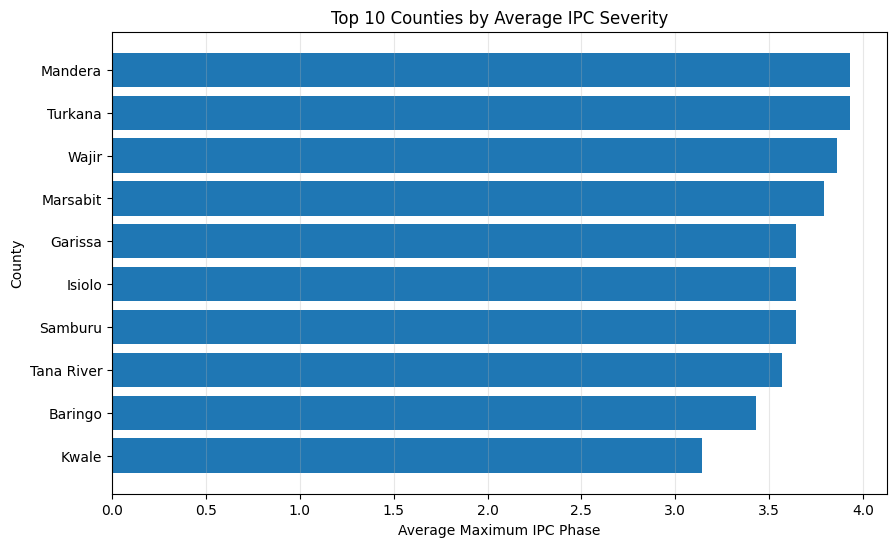

In [8]:
# Select top 10 counties by average IPC severity
top_10_ipc_counties = county_ipc_severity.head(10)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_ipc_counties["county"],
    top_10_ipc_counties["max_ipc_phase"]
)

plt.title("Top 10 Counties by Average IPC Severity")
plt.xlabel("Average Maximum IPC Phase")
plt.ylabel("County")

# Put highest-risk county at the top
plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()

### Interpretation

The chart shows the top 10 counties with the highest average IPC severity.

Mandera, Turkana, Wajir, and Marsabit appear as the highest-risk counties, with average IPC phases close to 4. This means these counties repeatedly experienced severe food insecurity conditions across the analysis periods.

This ranking helps identify priority counties for drought and food security early-warning monitoring.

## Counties with the Highest Average Phase 3+ Population Percentage

In this step, I calculate the average percentage of people in IPC Phase 3 or above for each county.

IPC Phase 3+ means people are in crisis-level food insecurity or worse. This helps identify counties where a larger share of the population was affected by serious food insecurity.

In [9]:
# Calculate average Phase 3+ population percentage by county
county_phase3_percentage = (
    df.groupby("county")["phase_3_plus_percentage"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
    .reset_index()
)

county_phase3_percentage.head(10)

,county,phase_3_plus_percentage
0,Turkana,0.303
1,Mandera,0.293
2,Marsabit,0.292
3,Wajir,0.250
4,Garissa,0.243
5,Isiolo,0.232
6,Tana River,0.232
7,Samburu,0.221
8,Baringo,0.164
9,Kwale,0.114


### Interpretation

The table shows the counties with the highest average share of people in IPC Phase 3 or above.

Turkana has the highest average Phase 3+ population percentage at about 30.3%, followed by Mandera, Marsabit, Wajir, and Garissa.

This means these counties repeatedly had a large proportion of their population facing crisis-level food insecurity or worse.

The results also overlap with the counties that had the highest average IPC severity, which suggests that Turkana, Mandera, Marsabit, Wajir, and Garissa should be treated as priority counties for drought and food security early-warning monitoring.

## Visualize Counties with the Highest Phase 3+ Population Percentage

In this step, I create a horizontal bar chart showing the top 10 counties with the highest average Phase 3+ population percentage.

This helps identify counties where a larger share of the population repeatedly faced crisis-level food insecurity or worse.

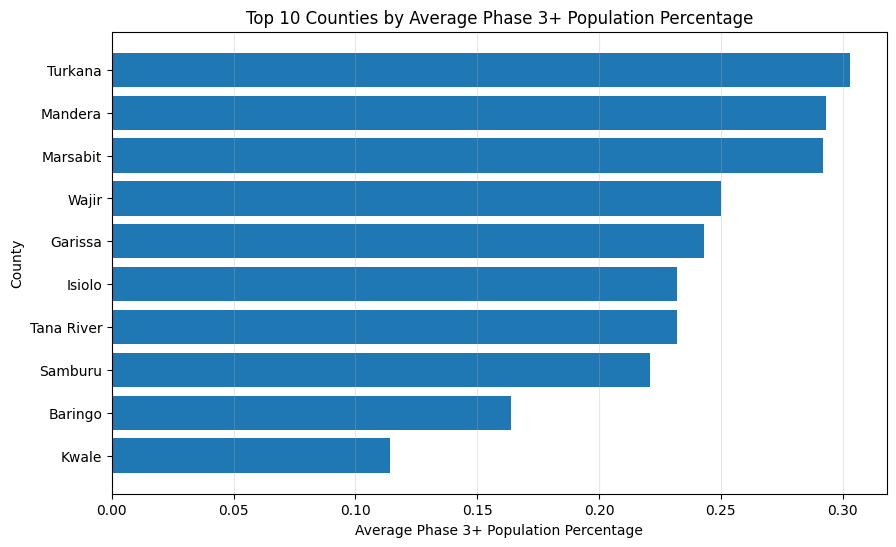

In [10]:
# Select top 10 counties by average Phase 3+ population percentage
top_10_phase3_counties = county_phase3_percentage.head(10)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_phase3_counties["county"],
    top_10_phase3_counties["phase_3_plus_percentage"]
)

plt.title("Top 10 Counties by Average Phase 3+ Population Percentage")
plt.xlabel("Average Phase 3+ Population Percentage")
plt.ylabel("County")

# Put highest-risk county at the top
plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()

### Interpretation

The chart shows the top 10 counties with the highest average share of people in IPC Phase 3 or above.

Turkana, Mandera, Marsabit, Wajir, and Garissa appear among the highest-risk counties. This means these counties repeatedly had a large proportion of their population facing crisis-level food insecurity or worse.

This reinforces the earlier finding that northern and arid/semi-arid counties are priority areas for drought and food security early-warning monitoring.

## Environmental Conditions in High-Risk Counties

In this step, I compare rainfall and NDVI conditions for the counties with the highest average Phase 3+ population percentage.

This helps check whether the most food-insecure counties also experienced weaker rainfall and vegetation health.

In [11]:
# Get the names of the top 10 counties by Phase 3+ population percentage
high_risk_counties = top_10_phase3_counties["county"].tolist()

# Filter the master dataset to only those high-risk counties
high_risk_df = df[df["county"].isin(high_risk_counties)]

# Calculate average rainfall and NDVI indicators for these counties
high_risk_environment = (
    high_risk_df.groupby("county")[
        [
            "phase_3_plus_percentage",
            "max_ipc_phase",
            "rainfall_3_month_avg",
            "rainfall_6_month_avg",
            "mean_ndvi",
            "ndvi_3_month_mean",
            "ndvi_6_month_mean",
            "ndvi_anomaly"
        ]
    ]
    .mean()
    .round(3)
    .sort_values("phase_3_plus_percentage", ascending=False)
    .reset_index()
)

high_risk_environment

,county,phase_3_plus_percentage,max_ipc_phase,rainfall_3_month_avg,rainfall_6_month_avg,mean_ndvi,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
0,Turkana,0.303,3.929,14.927,14.060,0.255,0.273,0.259,0.002
1,Mandera,0.293,3.929,21.215,16.258,0.313,0.375,0.331,-0.003
2,Marsabit,0.292,3.786,22.605,18.529,0.219,0.253,0.224,-0.002
3,Wajir,0.250,3.857,30.228,22.236,0.282,0.335,0.291,-0.001
4,Garissa,0.243,3.643,27.374,18.351,0.309,0.343,0.301,0.005
5,Tana River,0.232,3.571,27.523,19.257,0.331,0.361,0.323,0.005
6,Isiolo,0.232,3.643,16.323,12.152,0.272,0.318,0.277,-0.000
7,Samburu,0.221,3.643,27.172,22.778,0.372,0.409,0.374,-0.000
8,Baringo,0.164,3.429,41.650,39.093,0.513,0.535,0.516,-0.003
9,Kwale,0.114,3.143,55.651,43.937,0.528,0.544,0.504,0.003


### Interpretation

This table compares rainfall and NDVI conditions for the counties with the highest average Phase 3+ population percentage.

The results show that the highest-risk counties generally have low rainfall and weak vegetation health. Turkana has the highest average Phase 3+ population percentage at about 30.3%, with low 3-month and 6-month rainfall averages and low NDVI values. This suggests strong environmental stress.

Mandera, Marsabit, Wajir, Garissa, Isiolo, and Samburu also show high IPC severity together with relatively low rainfall and NDVI values. This indicates that these counties are important priority areas for drought and food security early-warning monitoring.

Baringo and Kwale have lower Phase 3+ percentages compared to the northern ASAL counties, and they also show higher NDVI values. This suggests that their vegetation conditions were relatively better, even though they still appear among the top 10 affected counties.

Overall, the results suggest that counties with higher food insecurity burden often experience weaker rainfall and vegetation conditions. However, the differences between counties also show that food insecurity is not explained by rainfall and NDVI alone. Other factors such as market prices, livestock conditions, conflict, income, and access to support may also play an important role.

## Mean NDVI in High-Risk Counties

In this step, I visualize the average NDVI values for the counties with the highest average Phase 3+ population percentage.

This helps identify which high-risk counties had the weakest vegetation health.

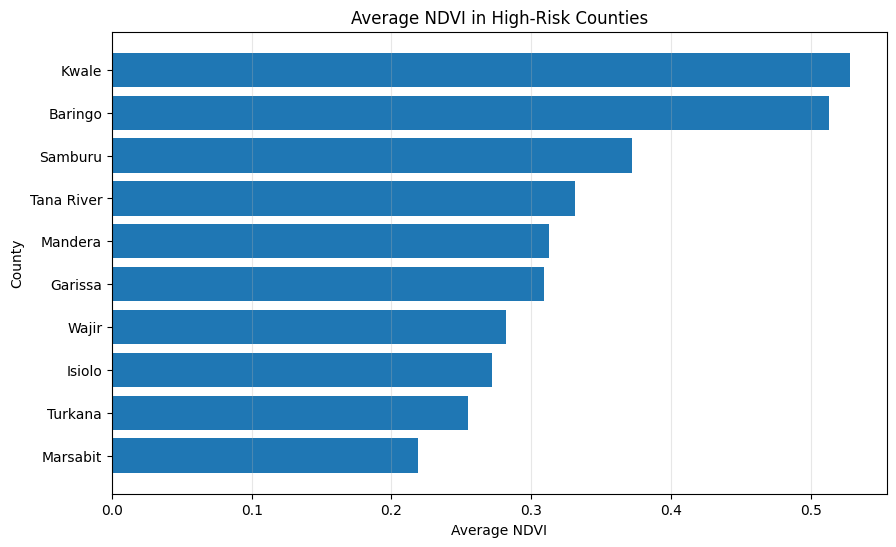

In [12]:
# Sort high-risk counties by mean NDVI from lowest to highest
high_risk_ndvi_sorted = high_risk_environment.sort_values(
    "mean_ndvi",
    ascending=True
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    high_risk_ndvi_sorted["county"],
    high_risk_ndvi_sorted["mean_ndvi"]
)

plt.title("Average NDVI in High-Risk Counties")
plt.xlabel("Average NDVI")
plt.ylabel("County")

plt.grid(axis="x", alpha=0.3)

plt.show()

### Interpretation

The chart shows average NDVI values for the highest-risk counties.

Counties with lower NDVI values had weaker vegetation health, which may indicate stronger drought stress. Counties such as Turkana, Marsabit, Isiolo, Wajir, and Garissa are important to monitor because they combine high food insecurity burden with relatively weak vegetation conditions.

Counties with higher NDVI values, such as Baringo and Kwale, had relatively greener vegetation. This suggests that food insecurity in those counties may also be influenced by other factors beyond vegetation health alone.

Overall, this chart helps show that NDVI is useful for identifying vegetation stress among high-risk counties, but it should be analyzed together with rainfall and other food security indicators.

## Rainfall Conditions in High-Risk Counties

In this step, I visualize the average 3-month rainfall for the counties with the highest average Phase 3+ population percentage.

This helps identify which high-risk counties had the weakest recent rainfall conditions.

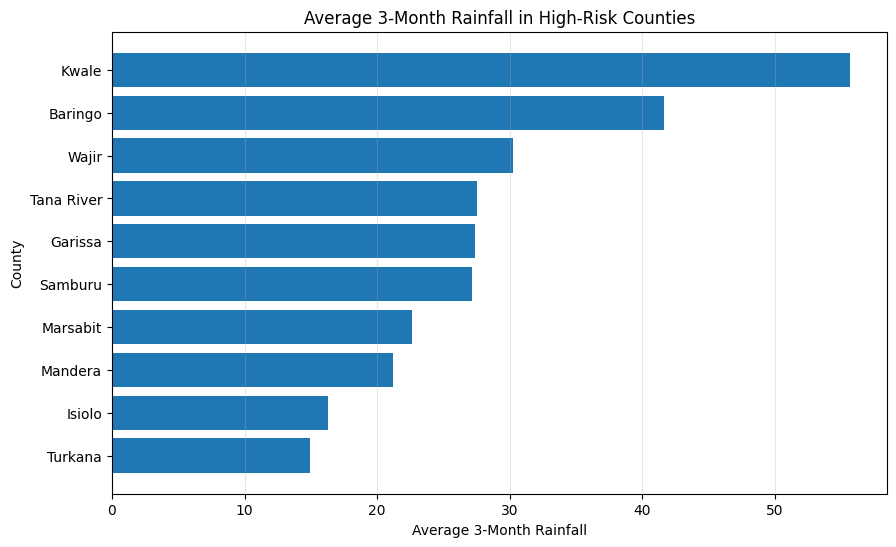

In [13]:
# Sort high-risk counties by 3-month rainfall average from lowest to highest
high_risk_rainfall_sorted = high_risk_environment.sort_values(
    "rainfall_3_month_avg",
    ascending=True
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    high_risk_rainfall_sorted["county"],
    high_risk_rainfall_sorted["rainfall_3_month_avg"]
)

plt.title("Average 3-Month Rainfall in High-Risk Counties")
plt.xlabel("Average 3-Month Rainfall")
plt.ylabel("County")

plt.grid(axis="x", alpha=0.3)

plt.show()

### Interpretation

The chart shows average 3-month rainfall conditions for the highest-risk counties.

Turkana, Isiolo, Mandera, and Marsabit have some of the lowest rainfall averages among the high-risk counties. This suggests that recent rainfall stress may be strongly linked to food insecurity risk in these areas.

Kwale and Baringo show higher average rainfall compared to the other high-risk counties. This suggests that food insecurity is not explained by rainfall alone. Other factors such as market prices, livestock conditions, income, conflict, or access to support may also affect food insecurity outcomes.

Overall, the chart shows that rainfall is an important early-warning indicator, but it should be combined with NDVI and other food security indicators for a stronger analysis.

## Relationship Between Rainfall and Phase 3+ Population Percentage

In this step, I create a scatter plot to compare 3-month rainfall average with the Phase 3+ population percentage.

This helps check whether counties and periods with lower rainfall tend to have a higher share of people in crisis-level food insecurity or worse.

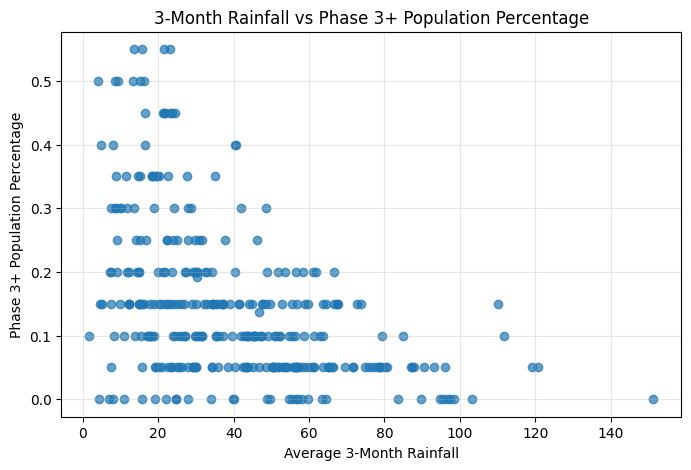

In [14]:
# Scatter plot: rainfall vs Phase 3+ population percentage
plt.figure(figsize=(8, 5))

plt.scatter(
    df["rainfall_3_month_avg"],
    df["phase_3_plus_percentage"],
    alpha=0.7
)

plt.title("3-Month Rainfall vs Phase 3+ Population Percentage")
plt.xlabel("Average 3-Month Rainfall")
plt.ylabel("Phase 3+ Population Percentage")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The scatter plot shows the relationship between average 3-month rainfall and the Phase 3+ population percentage.

Most of the highest Phase 3+ percentages occur when rainfall is low, especially below about 40 mm. This suggests that low recent rainfall is associated with a higher share of people facing crisis-level food insecurity or worse.

When rainfall is higher, the Phase 3+ population percentage is usually lower. However, the relationship is not perfect, which means rainfall alone does not fully explain food insecurity outcomes.

This supports the use of rainfall as an important early-warning indicator, but it should be combined with NDVI and other food security indicators for a stronger model.

## Relationship Between NDVI and Phase 3+ Population Percentage

In this step, I create a scatter plot to compare average NDVI with the Phase 3+ population percentage.

This helps check whether counties and periods with weaker vegetation health tend to have a higher share of people in crisis-level food insecurity or worse.

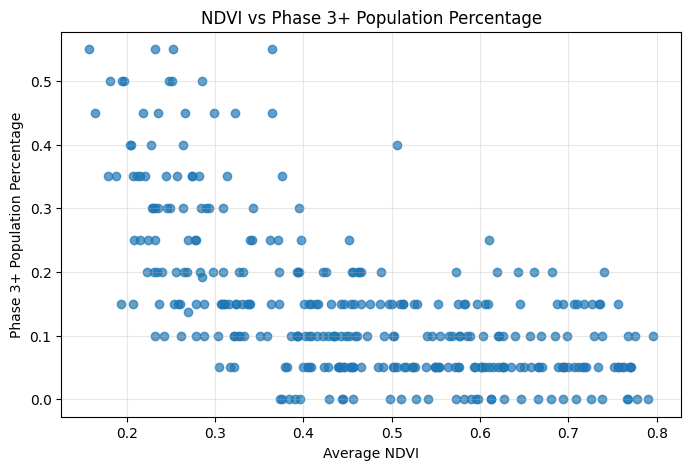

In [15]:
# Scatter plot: NDVI vs Phase 3+ population percentage
plt.figure(figsize=(8, 5))

plt.scatter(
    df["mean_ndvi"],
    df["phase_3_plus_percentage"],
    alpha=0.7
)

plt.title("NDVI vs Phase 3+ Population Percentage")
plt.xlabel("Average NDVI")
plt.ylabel("Phase 3+ Population Percentage")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The scatter plot shows a negative relationship between NDVI and the Phase 3+ population percentage.

Most of the highest Phase 3+ population percentages occur when NDVI is low, especially below about 0.35. This suggests that weaker vegetation health is associated with a higher share of people facing crisis-level food insecurity or worse.

When NDVI is higher, especially above about 0.55, the Phase 3+ population percentage is usually lower. This supports the use of NDVI as an important early-warning indicator for drought-related food insecurity.

However, the relationship is not perfect. Some records still show food insecurity even when NDVI is moderate, which means food insecurity is also affected by other factors such as rainfall history, food prices, livestock conditions, income, conflict, and market access.

## Correlation Between Environmental Indicators and Food Insecurity

In this step, I calculate correlations between rainfall, NDVI, and food insecurity indicators.

Correlation helps measure whether two variables move together.

A negative correlation means that as one variable increases, the other tends to decrease. For this project, a negative correlation between NDVI/rainfall and food insecurity would mean that lower environmental conditions are linked with higher food insecurity.

In [16]:
# Select key numeric columns for correlation analysis
correlation_columns = [
    "max_ipc_phase",
    "phase_3_plus_percentage",
    "rainfall_3_month_avg",
    "rainfall_6_month_avg",
    "mean_ndvi",
    "ndvi_3_month_mean",
    "ndvi_6_month_mean",
    "ndvi_anomaly"
]

# Calculate correlation table
correlation_table = df[correlation_columns].corr().round(3)

correlation_table

,max_ipc_phase,phase_3_plus_percentage,rainfall_3_month_avg,rainfall_6_month_avg,mean_ndvi,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
max_ipc_phase,1.000,0.764,-0.389,-0.544,-0.520,-0.576,-0.631,-0.190
phase_3_plus_percentage,0.764,1.000,-0.470,-0.585,-0.614,-0.692,-0.687,-0.368
rainfall_3_month_avg,-0.389,-0.470,1.000,0.829,0.719,0.706,0.554,0.445
rainfall_6_month_avg,-0.544,-0.585,0.829,1.000,0.700,0.748,0.695,0.511
mean_ndvi,-0.520,-0.614,0.719,0.700,1.000,0.940,0.867,0.393
ndvi_3_month_mean,-0.576,-0.692,0.706,0.748,0.940,1.000,0.941,0.432
ndvi_6_month_mean,-0.631,-0.687,0.554,0.695,0.867,0.941,1.000,0.292
ndvi_anomaly,-0.190,-0.368,0.445,0.511,0.393,0.432,0.292,1.000


### Interpretation

The correlation matrix shows clear negative relationships between environmental conditions and food insecurity outcomes.

Higher rainfall averages are associated with lower Phase 3+ population percentages. For example, the 6-month rainfall average has a moderately strong negative correlation with Phase 3+ population percentage (r = -0.585).

Vegetation health shows an even stronger relationship with food insecurity. The 3-month NDVI mean has a strong negative correlation with Phase 3+ population percentage (r = -0.692), while the 6-month NDVI mean also shows a strong negative correlation (r = -0.687).

These results suggest that weaker rainfall conditions and poorer vegetation health are strongly associated with higher food insecurity burden in the dataset. NDVI indicators appear to have slightly stronger relationships with food insecurity than rainfall indicators, which suggests they may be especially useful for drought and food security early-warning analysis.

However, these are correlations, not proof of causation. Food insecurity may also be influenced by other factors such as market prices, livestock conditions, conflict, income, and access to support.

## Correlation Heatmap

In this step, I visualize the correlation matrix using a heatmap.

This makes it easier to see which rainfall and NDVI indicators have stronger relationships with food insecurity outcomes.

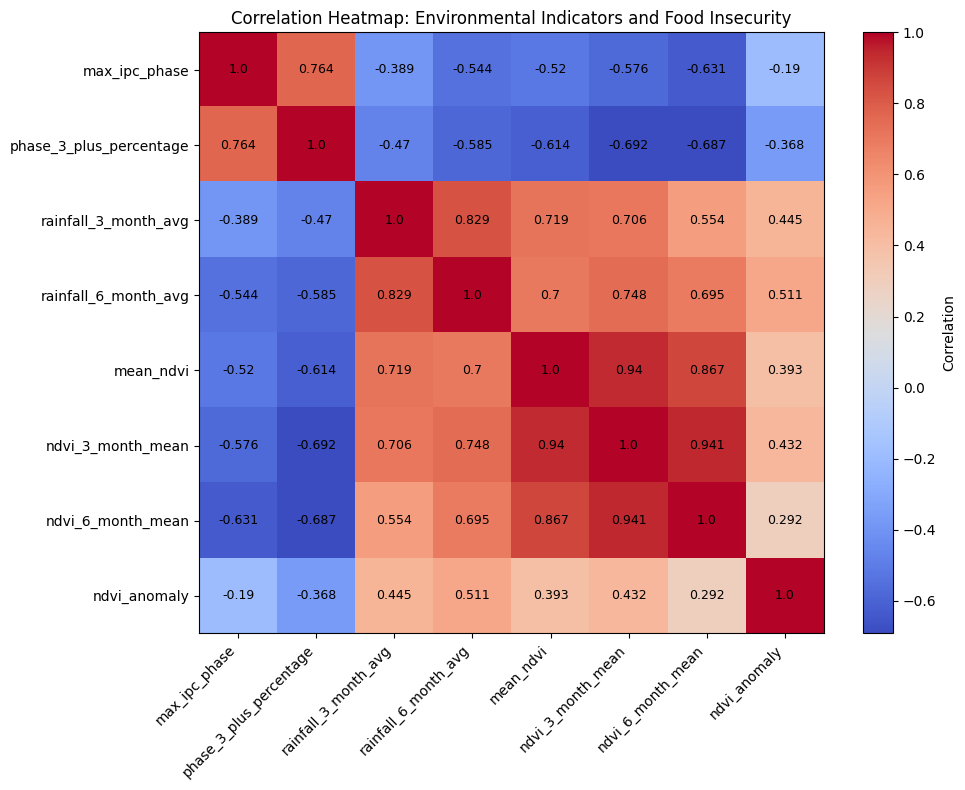

In [17]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))

plt.imshow(correlation_table, cmap="coolwarm", aspect="auto")

# Add axis labels
plt.xticks(range(len(correlation_table.columns)), correlation_table.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_table.index)), correlation_table.index)

# Add color bar
plt.colorbar(label="Correlation")

# Add values inside each cell
for i in range(len(correlation_table.index)):
    for j in range(len(correlation_table.columns)):
        plt.text(
            j, i,
            correlation_table.iloc[i, j],
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Correlation Heatmap: Environmental Indicators and Food Insecurity")
plt.tight_layout()
plt.show()

### Interpretation

The heatmap makes it easier to compare the strength and direction of relationships between rainfall, NDVI, and food insecurity indicators.

The strongest negative relationships with food insecurity are mostly found in the NDVI variables, especially the 3-month and 6-month NDVI means. This suggests that weaker vegetation health is strongly associated with higher food insecurity burden.

Rainfall variables also show negative relationships with food insecurity, especially the 6-month rainfall average. This suggests that prolonged rainfall conditions are also important for understanding food insecurity risk.

Overall, the heatmap shows that both rainfall and NDVI are useful environmental indicators, but NDVI appears to have slightly stronger relationships with food insecurity outcomes in this dataset.

## Strongest Correlations with Phase 3+ Population Percentage

In this step, I identify which environmental indicators have the strongest relationship with the Phase 3+ population percentage.

This helps show which rainfall and NDVI variables may be most useful for understanding food insecurity burden.

In [18]:
# Get correlations with Phase 3+ population percentage
phase3_correlations = (
    correlation_table["phase_3_plus_percentage"]
    .drop("phase_3_plus_percentage")
    .sort_values()
    .reset_index()
)

# Rename columns for clarity
phase3_correlations.columns = ["indicator", "correlation_with_phase3_plus_percentage"]

phase3_correlations

,indicator,correlation_with_phase3_plus_percentage
0,ndvi_3_month_mean,-0.692
1,ndvi_6_month_mean,-0.687
2,mean_ndvi,-0.614
3,rainfall_6_month_avg,-0.585
4,rainfall_3_month_avg,-0.470
5,ndvi_anomaly,-0.368
6,max_ipc_phase,0.764


### Interpretation

The correlation ranking shows that NDVI indicators have the strongest negative relationships with the Phase 3+ population percentage.

The 3-month NDVI mean has the strongest environmental relationship with Phase 3+ population percentage (r = -0.692), followed closely by the 6-month NDVI mean (r = -0.687). This suggests that weaker vegetation health is strongly associated with a higher share of people facing crisis-level food insecurity or worse.

Rainfall indicators also show negative relationships with Phase 3+ population percentage. The 6-month rainfall average has a stronger relationship (r = -0.585) than the 3-month rainfall average (r = -0.470), suggesting that longer rainfall conditions may be more useful than short-term rainfall alone.

Overall, the results suggest that NDVI may be a stronger environmental indicator than rainfall for explaining food insecurity burden in this dataset. However, these results show association, not causation. Food insecurity can also be affected by market prices, livestock conditions, conflict, income, and access to support.

## **Key Findings from the Master Dataset EDA**

This exploratory analysis produced several important findings:

1. **Highest-risk counties**
   Mandera, Turkana, Wajir, Marsabit, Garissa, Isiolo, Samburu, Tana River, Baringo, and Kwale appeared among the counties with the highest average IPC severity or highest Phase 3+ population percentage.

2. **Food insecurity burden**
   Turkana had the highest average Phase 3+ population percentage, followed by Mandera, Marsabit, Wajir, and Garissa. This means these counties repeatedly had a large share of their population facing crisis-level food insecurity or worse.

3. **Rainfall relationship**
   Lower rainfall was generally associated with higher food insecurity burden. The 6-month rainfall average had a stronger negative relationship with Phase 3+ population percentage than the 3-month rainfall average.

4. **NDVI relationship**
   NDVI showed a strong negative relationship with Phase 3+ population percentage. The 3-month NDVI mean had the strongest environmental relationship with food insecurity burden.

5. **Strongest environmental indicator**
   The 3-month NDVI mean was the strongest environmental indicator linked with Phase 3+ population percentage in this dataset.

6. **Important caution**
   These results show association, not causation. Food insecurity may also be affected by food prices, livestock conditions, conflict, income, market access, and humanitarian support.

In [19]:
# Save strongest correlations with Phase 3+ population percentage
output_path = "../02_data/processed/phase3_environment_correlation_summary.csv"

phase3_correlations.to_csv(output_path, index=False)

print("Correlation summary saved to:")
print(output_path)

Correlation summary saved to:
../02_data/processed/phase3_environment_correlation_summary.csv


## Notebook Conclusion

This notebook explored the final master dataset combining IPC food insecurity outcomes, CHIRPS rainfall indicators, and MODIS NDVI vegetation indicators.

The analysis showed that counties with higher food insecurity burden often had weaker rainfall and vegetation conditions. NDVI indicators, especially the 3-month and 6-month NDVI means, showed the strongest negative relationships with Phase 3+ population percentage.

This suggests that vegetation health is a useful signal for drought and food security early-warning analysis. Rainfall is also important, especially over longer periods, but NDVI may capture the actual land response more directly.

The next stage of the project will be to build a baseline model that uses rainfall and NDVI features to classify or predict food insecurity risk.